In [1]:
!pip install cornac pandas numpy scikit-learn matplotlib scipy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 7.4 MB/s eta 0:00:00


In [7]:
!curl -k -O https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -o ml-1m.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5778k  100 5778k    0     0  14.5M      0 --:--:-- --:--:-- --:--:-- 14.5M
Archive:  ml-1m.zip
   creating: ml-1m/
  inflating: ml-1m/movies.dat        
  inflating: ml-1m/ratings.dat       
  inflating: ml-1m/README            
  inflating: ml-1m/users.dat         


In [8]:
import pandas as pd

# Load ratings.dat from the extracted ml-1m directory
ratings_path = "ml-1m/ratings.dat"

df = pd.read_csv(
    ratings_path,
    sep="::",
    names=["UserID", "MovieID", "Rating", "Timestamp"],
    engine="python",
    dtype={"UserID": int, "MovieID": int, "Rating": float, "Timestamp": int}
)

# Retain only the required columns
df = df[["UserID", "MovieID", "Rating"]]

# Check dataset characteristics
num_users = df["UserID"].nunique()
num_movies = df["MovieID"].nunique()
num_interactions = len(df)

print(f"Users: {num_users:,}")
print(f"Movies: {num_movies:,}")
print(f"Interactions: {num_interactions:,}")

# Convert into the tuple format required by Cornac
# Depends on: df
data_original = list(df.itertuples(index=False, name=None))

print("Sample tuple for Cornac:", data_original[0])

Users: 6,040
Movies: 3,706
Interactions: 1,000,209
Sample tuple for Cornac: (1, 1193, 5.0)


In [9]:
# Depends on: df (from Step 2)
item_counts = df.groupby("MovieID")["UserID"].count().rename("interaction_count")

print("Movie Popularity Distribution Summary:")
print(item_counts.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]))

Movie Popularity Distribution Summary:
count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
90%       729.500000
95%      1051.500000
max      3428.000000
Name: interaction_count, dtype: float64


In [10]:
# Depends on: item_counts (from Step 3)
def classify_tail(count):
    if count < 50:
        return "long-tail"
    elif count < 250:
        return "mid-tail"
    else:
        return "short-tail"

item_stats = item_counts.to_frame()
item_stats["tail_category"] = item_stats["interaction_count"].apply(classify_tail)

summary = item_stats.groupby("tail_category").agg(
    movie_count=("interaction_count", "count"),
    rating_count=("interaction_count", "sum")
)
print("Tail Category Distribution:")
print(summary)

Tail Category Distribution:
               movie_count  rating_count
tail_category                           
long-tail             1192         22370
mid-tail              1298        168917
short-tail            1216        808922


In [12]:
# Depends on: data_original (from Step 2)
import cornac
from cornac.eval_methods import RatioSplit
from cornac.models import MF, PMF, BPR

SEED = 42
K_FACTORS = 32

# 1. Initialize RatioSplit
eval_method_orig = RatioSplit(
    data=data_original,
    test_size=0.2,
    rating_threshold=1.0,
    seed=SEED,
    verbose=False
)

# 2. Trigger data building automatically by accessing the train_set property
# (This avoids the manual .build() TypeError)
train_set_orig = eval_method_orig.train_set

# 3. Instantiate Models
mf_orig = MF(k=K_FACTORS, max_iter=30, learning_rate=0.01, lambda_reg=0.02, seed=SEED, verbose=False)
pmf_orig = PMF(k=K_FACTORS, max_iter=30, learning_rate=0.001, lambda_reg=0.01, seed=SEED, verbose=False)
bpr_orig = BPR(k=K_FACTORS, max_iter=30, learning_rate=0.01, lambda_reg=0.01, seed=SEED, verbose=False)

# 4. Train Models
print("Training baseline MF...")
mf_orig.fit(train_set_orig)

print("Training baseline PMF...")
pmf_orig.fit(train_set_orig)

print("Training baseline BPR...")
bpr_orig.fit(train_set_orig)

print("Baseline training complete.")

Training baseline MF...
Training baseline PMF...
Training baseline BPR...
Baseline training complete.


In [15]:
# Depends on: mf_orig, pmf_orig, bpr_orig, train_set_orig (from Step 5), item_stats (from Step 4)
import pandas as pd

def extract_embeddings(model, train_set, item_stats_df):
    # Detect the correct item factor attribute name
    if hasattr(model, "i_factors"):
        factors = model.i_factors
    elif hasattr(model, "v_factors"):
        factors = model.v_factors
    elif hasattr(model, "V"):
        factors = model.V
    else:
        raise AttributeError(f"Could not find item factors on model {type(model).__name__}")

    raw_movie_ids = [int(train_set.item_ids[i]) for i in range(train_set.num_items)]
    factors_df = pd.DataFrame(factors, index=raw_movie_ids)
    merged = factors_df.join(item_stats_df["tail_category"])
    return merged

emb_mf_orig = extract_embeddings(mf_orig, train_set_orig, item_stats)
emb_pmf_orig = extract_embeddings(pmf_orig, train_set_orig, item_stats)
emb_bpr_orig = extract_embeddings(bpr_orig, train_set_orig, item_stats)

print(f"Extracted MF item factors shape:  {emb_mf_orig.iloc[:, :K_FACTORS].shape}")
print(f"Extracted PMF item factors shape: {emb_pmf_orig.iloc[:, :K_FACTORS].shape}")
print(f"Extracted BPR item factors shape: {emb_bpr_orig.iloc[:, :K_FACTORS].shape}")

Extracted MF item factors shape:  (3675, 32)
Extracted PMF item factors shape: (3675, 32)
Extracted BPR item factors shape: (3675, 32)


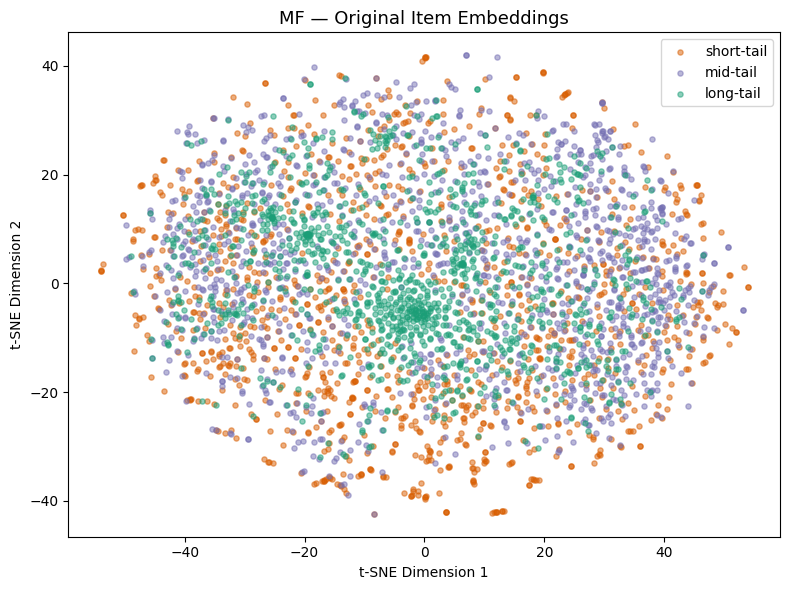

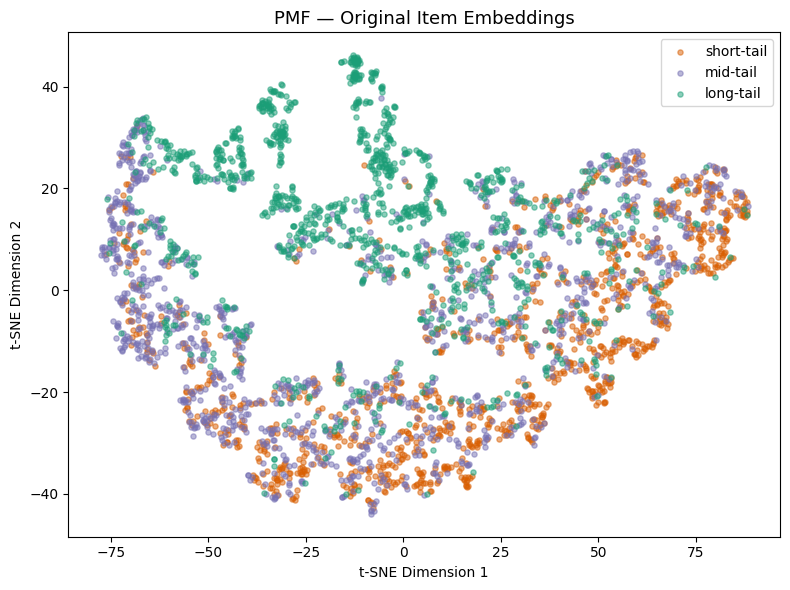

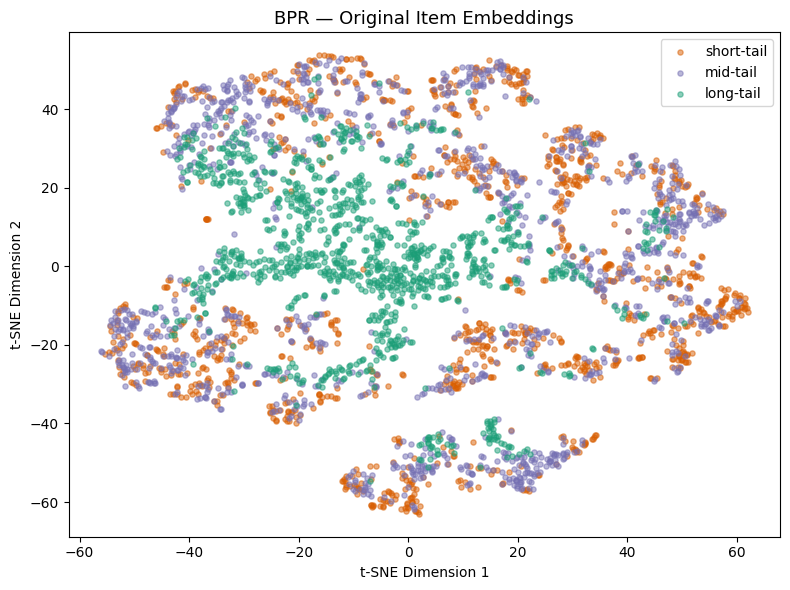

In [16]:
# Depends on: emb_mf_orig, emb_pmf_orig, emb_bpr_orig, SEED, K_FACTORS
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

COLOR_PALETTE = {
    "short-tail": "#D95F02",
    "mid-tail": "#7570B3",
    "long-tail": "#1B9E77"
}

def plot_tsne(emb_df, title, filename):
    factors = emb_df.iloc[:, :K_FACTORS].values
    labels = emb_df["tail_category"].values

    tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, max_iter=1000)
    coords = tsne.fit_transform(factors)

    plt.figure(figsize=(8, 6))
    for cat, color in COLOR_PALETTE.items():
        mask = (labels == cat)
        plt.scatter(coords[mask, 0], coords[mask, 1], c=color, label=cat, alpha=0.5, s=14)

    plt.title(title, fontsize=13)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

plot_tsne(emb_mf_orig, "MF — Original Item Embeddings", "tsne_mf_original.png")
plot_tsne(emb_pmf_orig, "PMF — Original Item Embeddings", "tsne_pmf_original.png")
plot_tsne(emb_bpr_orig, "BPR — Original Item Embeddings", "tsne_bpr_original.png")

In [17]:

num_extra_interactions = int(len(df) * 0.10)
short_tail_movie_ids = item_stats[item_stats["tail_category"] == "short-tail"].index.values

print(f"Target synthetic interactions to inject: {num_extra_interactions:,}")
print(f"Target short-tail movie pool size: {len(short_tail_movie_ids)}")

Target synthetic interactions to inject: 100,020
Target short-tail movie pool size: 1216


In [18]:
# Depends on: df, short_tail_movie_ids, num_extra_interactions, SEED
import numpy as np

# Empirical mean rating per short-tail movie
short_df = df[df["MovieID"].isin(short_tail_movie_ids)]
movie_mean_ratings = short_df.groupby("MovieID")["Rating"].mean().round()

existing_pairs = set(zip(df["UserID"], df["MovieID"]))
all_users = df["UserID"].unique()

np.random.seed(SEED)
synthetic_records = []

while len(synthetic_records) < num_extra_interactions:
    sampled_users = np.random.choice(all_users, size=num_extra_interactions)
    sampled_movies = np.random.choice(short_tail_movie_ids, size=num_extra_interactions)

    for u, i in zip(sampled_users, sampled_movies):
        if (u, i) not in existing_pairs:
            existing_pairs.add((u, i))
            r = movie_mean_ratings.loc[i]
            synthetic_records.append((u, i, r))
            if len(synthetic_records) == num_extra_interactions:
                break

df_synthetic = pd.DataFrame(synthetic_records, columns=["UserID", "MovieID", "Rating"])
print(f"Generated {len(df_synthetic):,} unique synthetic interactions.")

Generated 100,020 unique synthetic interactions.


In [19]:

df_biased = pd.concat([df, df_synthetic], ignore_index=True)

print(f"Original interactions: {len(df):,}")
print(f"Biased interactions:   {len(df_biased):,}")
print(f"Added interactions:    {len(df_biased) - len(df):,}")
print(f"Users unchanged:       {df_biased['UserID'].nunique() == df['UserID'].nunique()}")
print(f"Movies unchanged:      {df_biased['MovieID'].nunique() == df['MovieID'].nunique()}")

# Depends on: df_biased
data_biased = list(df_biased.itertuples(index=False, name=None))

Original interactions: 1,000,209
Biased interactions:   1,100,229
Added interactions:    100,020
Users unchanged:       True
Movies unchanged:      True


In [20]:
# Depends on: data_biased (from Step 10), SEED, K_FACTORS
eval_method_biased = RatioSplit(
    data=data_biased,
    test_size=0.2,
    rating_threshold=1.0,
    seed=SEED,
    verbose=False
)

# Trigger automatic split generation
train_set_biased = eval_method_biased.train_set

mf_biased = MF(k=K_FACTORS, max_iter=30, learning_rate=0.01, lambda_reg=0.02, seed=SEED, verbose=False)
pmf_biased = PMF(k=K_FACTORS, max_iter=30, learning_rate=0.001, lambda_reg=0.01, seed=SEED, verbose=False)
bpr_biased = BPR(k=K_FACTORS, max_iter=30, learning_rate=0.01, lambda_reg=0.01, seed=SEED, verbose=False)

print("Retraining MF on biased data...")
mf_biased.fit(train_set_biased)

print("Retraining PMF on biased data...")
pmf_biased.fit(train_set_biased)

print("Retraining BPR on biased data...")
bpr_biased.fit(train_set_biased)
print("Biased model training complete.")

Retraining MF on biased data...
Retraining PMF on biased data...
Retraining BPR on biased data...
Biased model training complete.


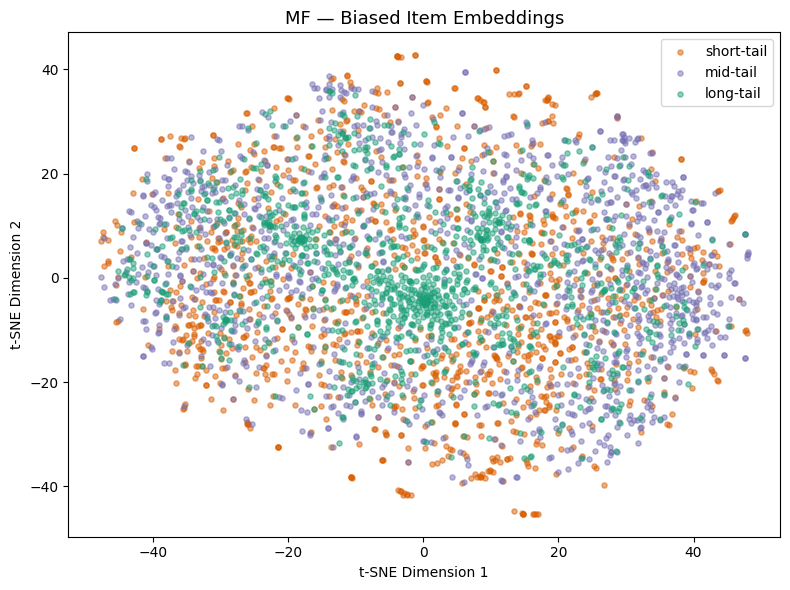

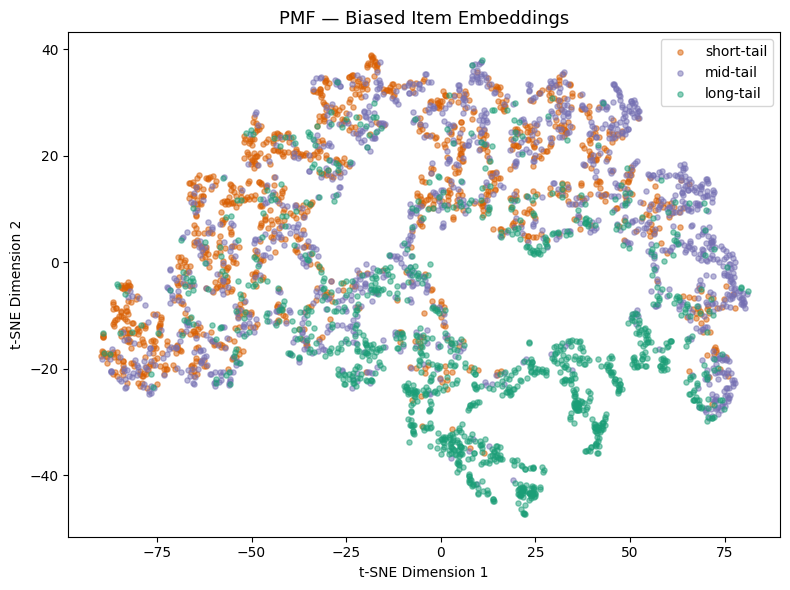

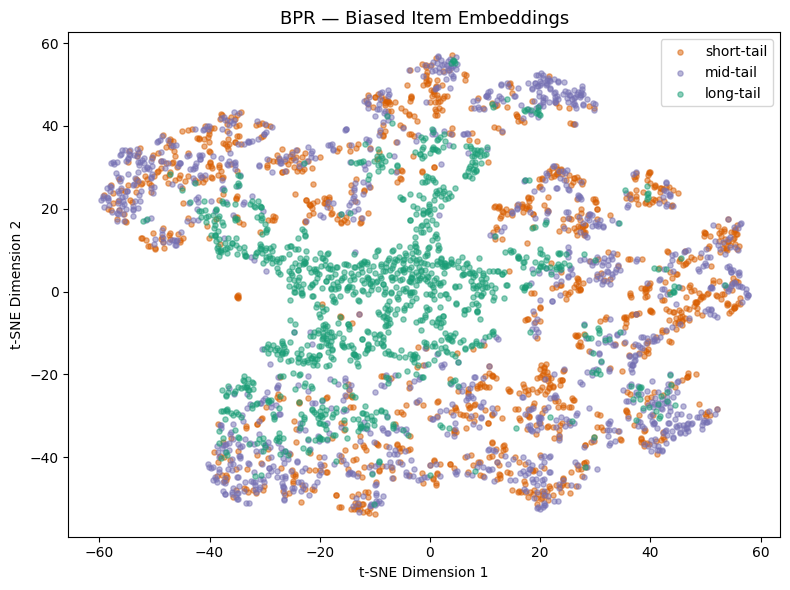

In [21]:
# Depends on: mf_biased, pmf_biased, bpr_biased, train_set_biased (from Step 11), item_stats
emb_mf_biased = extract_embeddings(mf_biased, train_set_biased, item_stats)
emb_pmf_biased = extract_embeddings(pmf_biased, train_set_biased, item_stats)
emb_bpr_biased = extract_embeddings(bpr_biased, train_set_biased, item_stats)

plot_tsne(emb_mf_biased, "MF — Biased Item Embeddings", "tsne_mf_biased.png")
plot_tsne(emb_pmf_biased, "PMF — Biased Item Embeddings", "tsne_pmf_biased.png")
plot_tsne(emb_bpr_biased, "BPR — Biased Item Embeddings", "tsne_bpr_biased.png")

In [22]:
# Depends on: emb_*_orig, emb_*_biased, item_stats, K_FACTORS
from scipy.linalg import orthogonal_procrustes

def compute_tail_drift(orig_df, biased_df, stats_df):
    common_ids = orig_df.index.intersection(biased_df.index)

    A = orig_df.loc[common_ids].iloc[:, :K_FACTORS].values
    B = biased_df.loc[common_ids].iloc[:, :K_FACTORS].values

    # Orthogonal Procrustes alignment
    R, _ = orthogonal_procrustes(B, A)
    B_aligned = B @ R

    # Euclidean drift in latent space
    euclidean = np.linalg.norm(B_aligned - A, axis=1)

    # Cosine drift (1 - cosine_similarity)
    norm_A = A / np.linalg.norm(A, axis=1, keepdims=True)
    norm_B = B_aligned / np.linalg.norm(B_aligned, axis=1, keepdims=True)
    cosine_dist = 1.0 - np.sum(norm_A * norm_B, axis=1)

    drift_df = pd.DataFrame({
        "euclidean_drift": euclidean,
        "cosine_drift": cosine_dist,
        "tail_category": stats_df.loc[common_ids, "tail_category"]
    }, index=common_ids)

    return drift_df.groupby("tail_category")[["euclidean_drift", "cosine_drift"]].mean()

print("--- MF Embedding Drift ---")
print(compute_tail_drift(emb_mf_orig, emb_mf_biased, item_stats))

print("\n--- PMF Embedding Drift ---")
print(compute_tail_drift(emb_pmf_orig, emb_pmf_biased, item_stats))

print("\n--- BPR Embedding Drift ---")
print(compute_tail_drift(emb_bpr_orig, emb_bpr_biased, item_stats))

--- MF Embedding Drift ---
               euclidean_drift  cosine_drift
tail_category                               
long-tail             0.466292      0.325490
mid-tail              0.975024      0.289790
short-tail            1.206664      0.321066

--- PMF Embedding Drift ---
               euclidean_drift  cosine_drift
tail_category                               
long-tail             0.082774      0.081484
mid-tail              0.069136      0.005292
short-tail            0.089138      0.003175

--- BPR Embedding Drift ---
               euclidean_drift  cosine_drift
tail_category                               
long-tail             0.121435      0.084482
mid-tail              0.185337      0.018243
short-tail            0.239176      0.018690


In [25]:
# Depends on: eval_method_orig, mf_orig, mf_biased, pmf_orig, pmf_biased, bpr_orig, bpr_biased, item_stats
import numpy as np

# Retrieve test set and unpack the (u, i, r) parallel arrays
test_ratings = eval_method_orig.test_set
u_indices, i_indices, ratings = test_ratings.uir_tuple

# -------------------------------------------------------------
# 1. Tail-Stratified RMSE for MF and PMF
# -------------------------------------------------------------
def compute_tail_rmse(model, train_set):
    # Mapping raw IDs -> model internal indices
    raw_to_model_idx = {int(train_set.item_ids[i]): i for i in range(train_set.num_items)}
    raw_to_model_uidx = {int(train_set.user_ids[u]): u for u in range(train_set.num_users)}

    errors = {"long-tail": [], "mid-tail": [], "short-tail": []}

    # Iterate across all ratings in the test set
    for u_idx, i_idx, r in zip(u_indices, i_indices, ratings):
        raw_uid = int(test_ratings.user_ids[u_idx])
        raw_mid = int(test_ratings.item_ids[i_idx])

        # Check if user and movie are known to this trained model
        if raw_uid in raw_to_model_uidx and raw_mid in raw_to_model_idx:
            m_u = raw_to_model_uidx[raw_uid]
            m_i = raw_to_model_idx[raw_mid]

            # Predict rating using model's rate method
            pred = model.rate(m_u, m_i)
            tail = item_stats.loc[raw_mid, "tail_category"]
            errors[tail].append((r - pred) ** 2)

    return {tail: float(np.sqrt(np.mean(errs))) for tail, errs in errors.items()}

print("--- Tail-Stratified RMSE ---")
print("MF Original: ", compute_tail_rmse(mf_orig, train_set_orig))
print("MF Biased:   ", compute_tail_rmse(mf_biased, train_set_biased))
print("PMF Original:", compute_tail_rmse(pmf_orig, train_set_orig))
print("PMF Biased:  ", compute_tail_rmse(pmf_biased, train_set_biased))

# -------------------------------------------------------------
# 2. Ranking Evaluation (NDCG@10) for BPR
# -------------------------------------------------------------
def compute_bpr_ndcg_at_k(model, train_set, k=10):
    raw_to_model_idx = {int(train_set.item_ids[i]): i for i in range(train_set.num_items)}
    raw_to_model_uidx = {int(train_set.user_ids[u]): u for u in range(train_set.num_users)}

    # Group test ratings by user: {raw_uid: set(raw_mids)}
    user_test_items = {}
    for u_idx, i_idx in zip(u_indices, i_indices):
        raw_uid = int(test_ratings.user_ids[u_idx])
        raw_mid = int(test_ratings.item_ids[i_idx])
        user_test_items.setdefault(raw_uid, set()).add(raw_mid)

    ndcg_list = []

    for raw_uid, test_mids in user_test_items.items():
        if raw_uid not in raw_to_model_uidx:
            continue

        m_u = raw_to_model_uidx[raw_uid]

        # Identify valid test items mapped to model space
        mapped_test_items = {raw_to_model_idx[mid] for mid in test_mids if mid in raw_to_model_idx}
        if not mapped_test_items:
            continue

        # Score all candidate items for this user: dot product u_factors x i_factors.T
        scores = model.u_factors[m_u] @ model.i_factors.T
        top_k_indices = np.argpartition(-scores, k)[:k]
        top_k_sorted = top_k_indices[np.argsort(-scores[top_k_indices])]

        # Calculate NDCG@K
        dcg = 0.0
        for rank, item_idx in enumerate(top_k_sorted):
            if item_idx in mapped_test_items:
                dcg += 1.0 / np.log2(rank + 2)

        idcg = sum(1.0 / np.log2(r + 2) for r in range(min(len(mapped_test_items), k)))
        ndcg_list.append(dcg / idcg if idcg > 0 else 0.0)

    return float(np.mean(ndcg_list))

print("\n--- BPR NDCG@10 ---")
print("BPR Original NDCG@10: ", compute_bpr_ndcg_at_k(bpr_orig, train_set_orig, k=10))
print("BPR Biased NDCG@10:   ", compute_bpr_ndcg_at_k(bpr_biased, train_set_biased, k=10))

--- Tail-Stratified RMSE ---
MF Original:  {'long-tail': 0.9648991113868006, 'mid-tail': 0.9060018921175826, 'short-tail': 0.8556230679635215}
MF Biased:    {'long-tail': 0.9043694881632969, 'mid-tail': 0.8492175414769985, 'short-tail': 0.8115283853920683}
PMF Original: {'long-tail': 1.048999339973202, 'mid-tail': 0.952319747284965, 'short-tail': 0.9170801292805175}
PMF Biased:   {'long-tail': 1.0383708131449632, 'mid-tail': 0.9507786583769113, 'short-tail': 0.9211666231494932}

--- BPR NDCG@10 ---
BPR Original NDCG@10:  0.05895204296788733
BPR Biased NDCG@10:    0.017393165580647685
